### 자동차 연비 회귀모델
- Auto MPG 데이터셋을 사용하여 1970년대 후반과 1980년대 초반의 자동차 연비를 예측하는 모델을 만듭니다.
- 이 정보에는 실린더 수, 배기량, 마력(horsepower), 공차 중량 같은 속성이 포함됩니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 구글 드라이브 마운트
# from google.colab import drive
# drive.mount('/content/drive')

# Working Directory 설정
# import os
# os.chdir('/content/drive/MyDrive/data')

파일은 auto-mpg.csv

In [3]:
df = pd.read_csv('./datas_dnn/auto-mpg.csv')

In [4]:
df.head()

,mpg,cyl,displ,hp,weight,accel,yr,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [5]:
df.isna().sum()

mpg       0
cyl       0
displ     0
hp        0
weight    0
accel     0
yr        0
origin    0
name      0
dtype: int64

In [6]:
y = df['mpg']

In [7]:
X = df.loc[ : ,'cyl' : 'origin' ]

In [8]:
X.head(2)

,cyl,displ,hp,weight,accel,yr,origin
0,8,307.0,130,3504,12.0,70,1
1,8,350.0,165,3693,11.5,70,1


In [9]:
y.head()

0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64

### 데이터 정규화

In [10]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

### X 데이터 정규화

In [11]:
# X데이터 정규화 객체
sc_X = MinMaxScaler()

In [12]:
X_scaled = sc_X.fit_transform(X)
X_scaled[:5]

array([[1.        , 0.61757106, 0.45652174, 0.5361497 , 0.23809524,
        0.        , 0.        ],
       [1.        , 0.72868217, 0.64673913, 0.58973632, 0.20833333,
        0.        , 0.        ],
       [1.        , 0.64599483, 0.56521739, 0.51686986, 0.17857143,
        0.        , 0.        ],
       [1.        , 0.60981912, 0.56521739, 0.51601928, 0.23809524,
        0.        , 0.        ],
       [1.        , 0.60465116, 0.51086957, 0.52055571, 0.14880952,
        0.        , 0.        ]])

### y 데이터 2차원 reshaphe, 정규화
- 딥러닝에서 데이터 학습이 더 잘됨

In [13]:
# y데이터 정규화 객체
sc_y = MinMaxScaler()

In [14]:
y.shape

(392,)

In [15]:
y.values.reshape(-1,1)[:5]

array([[18.],
       [15.],
       [18.],
       [16.],
       [17.]])

In [16]:
y_scaled = sc_y.fit_transform(y.values.reshape(-1,1))

In [17]:
y_scaled[:5]

array([[0.2393617 ],
       [0.15957447],
       [0.2393617 ],
       [0.18617021],
       [0.21276596]])

### 학습, 테스트 데이터 분할

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, 
    test_size=0.2, 
    random_state=42)

### 딥러닝 모델링
- 텐서플로 2.19 버전에서 바뀐 내용: 옵티마이저 방법을 문자열 형식 대신 객체형식으로 하면 직렬화를 더 작한다고 함.

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from keras.optimizers import Adam

I0000 00:00:1788225255.615347 4123657 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788225255.672870 4123657 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788225257.306776 4123657 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [21]:
def build_model( input_dim ) :
  model = Sequential()
  model.add( keras.Input(shape=(input_dim,)) )
  model.add( Dense(64, activation='relu') )
  model.add( Dense(64, activation='relu') )
  model.add( Dense(1, activation='linear'))
    
  model.compile( Adam(learning_rate=0.001),
                 loss='mse', 
                 metrics=['mae'] )
  return model

In [22]:
model = build_model( X_train.shape[1] )

I0000 00:00:1788225258.469062 4123657 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
X_train.shape

(313, 7)

In [25]:
history = model.fit(
    X_train, y_train, 
    epochs = 500, 
    validation_split = 0.2,
    verbose = 0    
)

I0000 00:00:1788225259.769426 4123782 service.cc:153] XLA service 0x7aa74c031e10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788225259.769456 4123782 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.1)
I0000 00:00:1788225259.786393 4123782 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788225259.895698 4123782 cuda_dnn.cc:461] Loaded cuDNN version 92501
I0000 00:00:1788225259.903824 4123782 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1256__.9
I0000 00:00:1788225260.080357 4123782 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set in

In [26]:
# 화면으로 출력한 결과가 기록 되어 있음
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

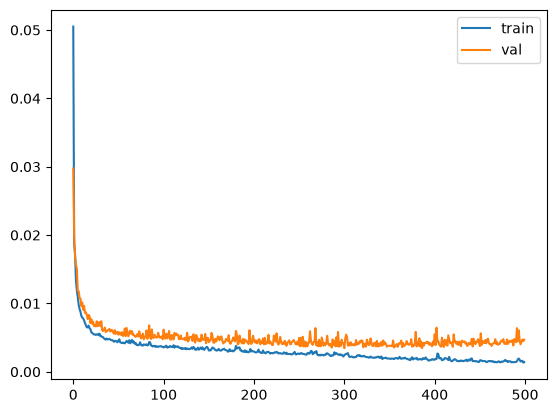

In [27]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'val'])
plt.show()

이 그래프를 보면 수 백번 에포크를 진행한 이후에는 모델이 거의 향상되지 않는 것 같습니다. model.fit 메서드를 수정하여 검증 점수가 향상되지 않으면 자동으로 훈련을 멈추도록 만들어 보죠. 에포크마다 훈련 상태를 점검하기 위해 EarlyStopping 콜백(callback)을 사용하겠습니다. 지정된 에포크 횟수 동안 성능 향상이 없으면 자동으로 훈련이 멈춥니다.

이 콜백에 대해 더 자세한 내용은 여기를 참고하세요.
https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping

### 학습 자동 중단

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

In [29]:
# 깡통 모델 생성
model = build_model(X_train.shape[1])

In [30]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# callback, 함수
# EarlyStopping(monitor='val_loss', mode=validation 로스 최소, patience=loss 올라가는것을 몇번 참느냐?, 
#  restore_best_weights=True weight가 가장 좋았던 상태로 되돌리기 )
early_stopping = EarlyStopping(
    monitor='val_loss', 
    mode='min', 
    patience=5, 
    restore_best_weights=True) # 가장 베스트한 지점으로 되돌아감

from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    filepath='./models/autosave_model.keras',
    monitor='val_loss',                         # 기준 지표
    save_best_only=True,                        # 좋아졌을 때만 저장
    mode='min',                                 # val_loss는 낮을수록 좋음
    verbose=1
)

In [32]:
# 학습
history2 = model.fit(
    X_train, 
    y_train, 
    epochs = 100000, 
    validation_split=0.2, 
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/100000


I0000 00:00:1788225307.062345 4123779 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_34736__.9


1/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 0.3419 - mae: 0.5543

I0000 00:00:1788225307.583745 4123779 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_34736__.9


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.1721 - mae: 0.3558
Epoch 1: val_loss improved from None to 0.06436, saving model to ./models/autosave_model.keras

Epoch 1: finished saving model to ./models/autosave_model.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - loss: 0.1721 - mae: 0.3558 - val_loss: 0.0644 - val_mae: 0.2169
Epoch 2/100000
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0498 - mae: 0.1806
Epoch 2: val_loss improved from 0.06436 to 0.03856, saving model to ./models/autosave_model.keras

Epoch 2: finished saving model to ./models/autosave_model.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0469 - mae: 0.1807 - val_loss: 0.0386 - val_mae: 0.1611
Epoch 3/100000
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0391 - mae: 0.1589
Epoch 3: val_loss improved from 0.03856 to 0.01976, saving model to ./models/autosave_model.keras

Epoch 3: finished saving model to ./models/autosave_model.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0339 - mae: 0.1555 - val_l

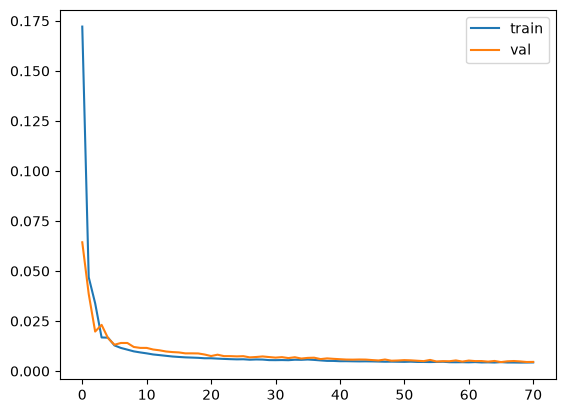

In [33]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.legend(['train', 'val'])
plt.show()

### 평가

In [34]:
model.evaluate(X_test, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - loss: 0.0052 - mae: 0.0531


[0.005209468305110931, 0.05307538062334061]

In [35]:
# 2.19 버전부터는 .keras를 권장함
model.save('./models/mpg_model.keras')

In [36]:
model_2 = keras.models.load_model('./models/mpg_model.keras')
model_2.evaluate(X_test, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0052 - mae: 0.0531


[0.005209468305110931, 0.05307538062334061]